In [1]:
%pip install torchgeo timm -q

import os
import time
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as transforms
import timm
from torchgeo.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve

import optuna
import logging

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 13.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 871.8/871.8 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 34.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
class LootingDataset(Dataset):
    """
    Custom PyTorch Dataset to load images from 'Looted' and 'NotLooted' folders.
    """
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.classes = ['NotLooted', 'Looted'] # NotLooted = 0, Looted = 1
        
        self.image_paths = []
        self.labels = []
        
        # Populate image paths and corresponding class labels
        for class_idx, class_name in enumerate(self.classes):
            class_folder = os.path.join(data_dir, class_name)
            if not os.path.isdir(class_folder):
                continue
            for img_name in os.listdir(class_folder):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_folder, img_name))
                    self.labels.append(class_idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        img_path = self.image_paths[index]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[index]
        return image, label


class TransformedSubset(Dataset):
    """
    Wraps a Subset of a dataset and applies a specific transform.
    Allows us to apply separate augmentations to training and validation splits.
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

In [4]:
DATA_DIR = "/kaggle/input/datasets/abdelazizamr837/egyptian-archaeological-site-looting/data"


if DATA_DIR is None:
    raise FileNotFoundError("Could not automatically locate the dataset folder. Please verify your dataset input on the right panel.")
else:
    print(f"Dataset successfully located at: {DATA_DIR}")

# 1. Grab pre-trained weights to configure the optimal inference transform
weights = ResNet50_Weights.SENTINEL2_RGB_MOCO
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# 2. Configure advanced training transforms (scale invariance & regularization)
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=360),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)) 
])

# 3. Load raw dataset 
base_dataset = LootingDataset(data_dir=DATA_DIR)
print(f"Total dataset size loaded: {len(base_dataset)} images")

Dataset successfully located at: /kaggle/input/datasets/abdelazizamr837/egyptian-archaeological-site-looting/data
Total dataset size loaded: 504 images


In [5]:
class EarlyStopping:
    """
    Early stopping to stop the training when validation accuracy stops improving.
    """
    def __init__(self, patience=7, min_delta=0.1, path='checkpoint.pth'):
        """
        Args:
            patience (int): How long to wait after last time validation accuracy improved.
                            Default: 7
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0.1 (0.1% change in accuracy)
            path (str): Path for the checkpoint to be saved to.
                            Default: 'checkpoint.pth'
        """
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_acc_max = 0.0

    def __call__(self, val_acc, model):
        
        score = val_acc

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
            self.counter = 0

    def save_checkpoint(self, val_acc, model):
        """Saves model when validation accuracy increases."""
        torch.save(model.state_dict(), self.path)
        print(f"⭐ Validation accuracy increased ({self.val_acc_max:.2f}% --> {val_acc:.2f}%). Saving best checkpoint to: {self.path}")
        self.val_acc_max = val_acc

In [5]:
# First Training Cell

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
labels_array = np.array(base_dataset.labels)

print(f"Starting 5-Fold Cross-Validation on: {device}")

# We will collect the best metrics of each fold to output a summary at the end
cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(base_dataset)), labels_array)):
    print(f"\n=========================================")
    print(f"            TRAINING FOLD {fold + 1}/5")
    print(f"=========================================")
    
    
    train_fold_dataset = TransformedSubset(Subset(base_dataset, train_idx), transform=train_transforms)
    val_fold_dataset = TransformedSubset(Subset(base_dataset, val_idx), transform=val_transforms)
    
    
    print(f"📊 Fold Dataset Split: {len(train_fold_dataset)} Training images | {len(val_fold_dataset)} Validation images")
    
    
    train_loader = DataLoader(train_fold_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_fold_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
    
    
    model = timm.create_model('resnet50', in_chans=3, num_classes=2)
    model.load_state_dict(weights.get_state_dict(progress=True), strict=False)
    
   
    for param in model.parameters():
        param.requires_grad = False
    model = model.to(device)
    
    head_params = list(model.get_classifier().parameters())
    for param in head_params:
        param.requires_grad = True
        
    optimizer = optim.AdamW(head_params, lr=1e-3, weight_decay=1e-2)
    
   
    EPOCHS = 15  
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    fold_model_path = f'/kaggle/working/resnet50_fold_{fold + 1}.pth'
    early_stopping = EarlyStopping(patience=7, min_delta=0.001, path=fold_model_path)
    
    
    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_epoch = 0
    
    # --- FOLD TRAINING LOOP ---
    print(f"\n🏁 Commencing training loop for Fold {fold+1}...")
    for epoch in range(EPOCHS):
        start_time = time.time()
        
        # --- Training Phase ---
        model.train()
        for m in model.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval() # Keep BN frozen
                
        train_loss, train_correct, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            
        epoch_train_loss = train_loss / total_train
        epoch_train_acc = (train_correct / total_train) * 100
        
        # --- Validation Phase ---
        model.eval()
        val_loss, val_correct, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = (val_correct / total_val) * 100
        
        scheduler.step()
        elapsed_time = time.time() - start_time
        
        # Determine if this epoch is the best performing for validation accuracy
        is_best = False
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_val_loss = epoch_val_loss
            best_epoch = epoch + 1
            is_best = True
        
        # Print status
        status_msg = (f"Fold {fold+1} | Epoch [{epoch+1:02d}/{EPOCHS:02d}] ({elapsed_time:.1f}s) | "
                      f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
                      f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%")
        
        if is_best:
            status_msg += " ⭐ New Best Acc!"
            
        print(status_msg)
        
        # Call Early Stopping
        early_stopping(epoch_val_loss, model)
        if early_stopping.early_stop:
            print(f"🛑 Fold {fold+1} early stopping triggered.")
            break
            
    # Save fold results
    cv_results.append({
        'fold': fold + 1,
        'best_epoch': best_epoch,
        'best_acc': best_val_acc,
        'best_loss': best_val_loss
    })
    
    print(f"\n✅ Fold {fold+1} Training Completed!")
    print(f"   🏆 Best Performance: Epoch {best_epoch:02d} | Val Acc: {best_val_acc:.2f}% | Val Loss: {best_val_loss:.4f}")

# =====================================================================
# FINAL CROSS-VALIDATION SUMMARY REPORT
# =====================================================================
print("\n" + "="*60)
print("🎉 ALL 5 FOLDS TRAINED SUCCESSFULLY! FINAL CV REPORT:")
print("="*60)

acc_list = []
for result in cv_results:
    print(f"Fold {result['fold']}: Best Epoch {result['best_epoch']:02d} | Val Acc: {result['best_acc']:.2f}% | Val Loss: {result['best_loss']:.4f}")
    acc_list.append(result['best_acc'])

mean_acc = np.mean(acc_list)
std_acc = np.std(acc_list)

print("-"*60)
print(f"🔥 Overall 5-Fold Cross-Validation Accuracy: {mean_acc:.2f}% +/- {std_acc:.2f}%")
print("="*60)

Starting 5-Fold Cross-Validation on: cuda

            TRAINING FOLD 1/5
📊 Fold Dataset Split: 403 Training images | 101 Validation images
Downloading: "https://hf.co/torchgeo/resnet50_sentinel2_rgb_moco/resolve/efd9723b59a88e9dc1420dc1e96afb25b0630a3c/resnet50_sentinel2_rgb_moco-2b57ba8b.pth" to /root/.cache/torch/hub/checkpoints/resnet50_sentinel2_rgb_moco-2b57ba8b.pth


100%|██████████| 90.0M/90.0M [00:26<00:00, 3.53MB/s]



🏁 Commencing training loop for Fold 1...
Fold 1 | Epoch [01/15] (136.4s) | Train Loss: 0.6896 - Train Acc: 53.85% | Val Loss: 0.6673 - Val Acc: 73.27% ⭐ New Best Acc!
⭐ Validation loss decreased. Saving best checkpoint to: /kaggle/working/resnet50_fold_1.pth
Fold 1 | Epoch [02/15] (134.4s) | Train Loss: 0.6580 - Train Acc: 72.95% | Val Loss: 0.6499 - Val Acc: 66.34%
⭐ Validation loss decreased. Saving best checkpoint to: /kaggle/working/resnet50_fold_1.pth
Fold 1 | Epoch [03/15] (129.2s) | Train Loss: 0.6378 - Train Acc: 74.19% | Val Loss: 0.6330 - Val Acc: 69.31%
⭐ Validation loss decreased. Saving best checkpoint to: /kaggle/working/resnet50_fold_1.pth
Fold 1 | Epoch [04/15] (135.4s) | Train Loss: 0.6274 - Train Acc: 72.70% | Val Loss: 0.6217 - Val Acc: 69.31%
⭐ Validation loss decreased. Saving best checkpoint to: /kaggle/working/resnet50_fold_1.pth
Fold 1 | Epoch [05/15] (132.0s) | Train Loss: 0.6101 - Train Acc: 74.69% | Val Loss: 0.6124 - Val Acc: 70.30%
⭐ Validation loss decrea

Running Out-of-Fold (OOF) Evaluation with Test-Time Augmentation...
Evaluating Fold 1/5 on its validation split...
Evaluating Fold 2/5 on its validation split...
Evaluating Fold 3/5 on its validation split...
Evaluating Fold 4/5 on its validation split...
Evaluating Fold 5/5 on its validation split...

 Final 5-Fold Out-of-Fold Accuracy (with TTA): 71.23%

Classification Report:
              precision    recall  f1-score   support

   NotLooted       0.67      0.80      0.73       247
      Looted       0.76      0.63      0.69       257

    accuracy                           0.71       504
   macro avg       0.72      0.71      0.71       504
weighted avg       0.72      0.71      0.71       504



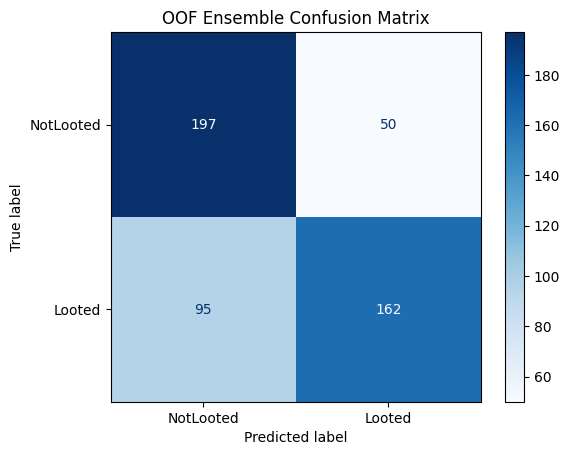

In [6]:
# First OOF

oof_preds = np.zeros(len(base_dataset))
oof_labels = np.zeros(len(base_dataset))

print("Running Out-of-Fold (OOF) Evaluation with Test-Time Augmentation...")

# We iterate through the exact same 5-fold splits
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(base_dataset)), labels_array)):
    print(f"Evaluating Fold {fold+1}/5 on its validation split...")
    
    # Load the model trained on this specific fold
    fold_model = timm.create_model('resnet50', in_chans=3, num_classes=2)
    fold_model.load_state_dict(torch.load(f'/kaggle/working/resnet50_fold_{fold+1}.pth'))
    fold_model = fold_model.to(device)
    fold_model.eval()
    
    # Create validation loader for this specific fold
    val_fold_dataset = TransformedSubset(Subset(base_dataset, val_idx), transform=val_transforms)
    val_loader = DataLoader(val_fold_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
    
    fold_preds = []
    fold_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            
            # Predict using Test-Time Augmentation (TTA)
            outputs_orig = fold_model(images)
            outputs_hflip = fold_model(torch.flip(images, dims=[3]))
            outputs_vflip = fold_model(torch.flip(images, dims=[2]))
            
            avg_outputs = (outputs_orig + outputs_hflip + outputs_vflip) / 3.0
            
            _, preds = torch.max(avg_outputs, 1)
            fold_preds.extend(preds.cpu().numpy())
            fold_labels.extend(labels.numpy())
            
    # Store predictions and labels into the correct indices of the full arrays
    oof_preds[val_idx] = fold_preds
    oof_labels[val_idx] = fold_labels

# Calculate overall OOF Accuracy across all 403 images
oof_accuracy = accuracy_score(oof_labels, oof_preds) * 100
print(f"\n=========================================")
print(f" Final 5-Fold Out-of-Fold Accuracy (with TTA): {oof_accuracy:.2f}%")
print(f"=========================================")
print("\nClassification Report:")
print(classification_report(oof_labels, oof_preds, target_names=base_dataset.classes))

# Plot visual Confusion Matrix
cm = confusion_matrix(oof_labels, oof_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=base_dataset.classes)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("OOF Ensemble Confusion Matrix")
plt.show()

In [9]:
# =================================================================
# OPTIONAL: HYPERPARAMETER OPTIMIZATION (OPTUNA)
# =================================================================
# Set this to True ONLY if you want to rerun the multi-hour search space optimization.
# Otherwise, the pipeline uses the pre-optimized hyperparameters: 
# lr = 1.0e-5, weight_decay = 1.0e-2

RUN_OPTUNA_SEARCH = False

if RUN_OPTUNA_SEARCH:
    import optuna
    
    # Set Optuna logging to warning to keep the output clean
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Re-ensure labels array is accessible
    labels_array = np.array(base_dataset.labels)

    def objective(trial):
        # 1. Suggest hyperparameters
        lr = trial.suggest_float('lr', 1e-5, 3e-4, log=True)
        weight_decay = trial.suggest_float('weight_decay', 1e-4, 1e-2, log=True)
        
        # 2. Extract Fold 1 split exactly
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        splits = list(skf.split(np.zeros(len(base_dataset)), labels_array))
        train_idx, val_idx = splits[0] 
        
        train_fold_dataset = TransformedSubset(Subset(base_dataset, train_idx), transform=train_transforms)
        val_fold_dataset = TransformedSubset(Subset(base_dataset, val_idx), transform=val_transforms)
        
        train_loader = DataLoader(train_fold_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_fold_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
        
        # 3. Load the saved Fold 1 weights (First version with standard single-layer head)
        model = timm.create_model('resnet50', in_chans=3, num_classes=2)
        model.load_state_dict(torch.load('/kaggle/working/resnet50_fold_1.pth', map_location=device))
        
        # 4. PARTIAL FREEZING: Freeze early blocks, unfreeze layer3, layer4, and fc
        for param in model.parameters():
            param.requires_grad = False
            
        for param in model.layer3.parameters():
            param.requires_grad = True
            
        for param in model.layer4.parameters():
            param.requires_grad = True
            
        for param in model.fc.parameters():
            param.requires_grad = True
            
        model = model.to(device)
        
        # 5. Optimizer and Criterion
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        
        best_val_acc = 0.0
        TRIAL_EPOCHS = 8  # 8 epochs is plenty to evaluate learning rate convergence
        
        for epoch in range(TRIAL_EPOCHS):
            model.train()
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
            model.eval()
            val_correct, total_val = 0, 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    _, predicted = outputs.max(1)
                    total_val += labels.size(0)
                    val_correct += predicted.eq(labels).sum().item()
                    
            val_acc = (val_correct / total_val) * 100
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                
            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
                
        return best_val_acc

    # Run the study
    print("Running Optuna Study for Partial Fine-Tuning (Layer 3 & 4)...")
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=15)

    # Print results
    print("\n" + "="*50)
    print("🏆 OPTUNA PARAMETER TUNING COMPLETE!")
    print("="*50)
    print(f"Best Trial Validation Accuracy: {study.best_trial.value:.2f}%")
    print("Best Hyperparameters found:")
    for key, value in study.best_trial.params.items():
        print(f"  {key}: {value:.2e}" if key == 'lr' else f"  {key}: {value:.4f}")
    print("="*50)

else:
    print("Skipping active Optuna hyperparameter tuning study to preserve compute.")
    print("Using established pre-tuned parameters:")
    print("  - learning_rate (Backbone): 1.0e-5")
    print("  - learning_rate (Head): 1.0e-4")
    print("  - weight_decay: 1.0e-2")

Running Optuna Study for Partial Fine-Tuning (Layer 3 & 4)...

🏆 OPTUNA PARAMETER TUNING COMPLETE!
Best Trial Validation Accuracy: 81.19%
Best Hyperparameters found:
  lr: 6.87e-05
  weight_decay: 0.0035


In [ ]:
optimized_lr = 6.87e-05   # if run optuna ==> change to best_lr variable
optimized_wd = 0.003  # if run optuna ==> change to best_wd variable

print(f"Using Regularized Fine-Tuning -> LR: {optimized_lr:.2e} | Weight Decay: {optimized_wd:.4f}\n")

# Re-ensure labels array is accessible
labels_array = np.array(base_dataset.labels)
final_cv_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =====================================================================
# 3. 5-FOLD FINE-TUNING LOOP
# =====================================================================
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(base_dataset)), labels_array)):
    print(f"\n=========================================")
    print(f"      PARTIAL FINE-TUNING FOLD {fold + 1}/5")
    print(f"=========================================")
    
    # Standard disk-loading subsets using your existing dataset splits
    train_fold_dataset = TransformedSubset(Subset(base_dataset, train_idx), transform=train_transforms)
    val_fold_dataset = TransformedSubset(Subset(base_dataset, val_idx), transform=val_transforms)
    
    train_loader = DataLoader(train_fold_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_fold_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
    
    # Load raw Stage 1 weights
    model = timm.create_model('resnet50', in_chans=3, num_classes=2)
    model.load_state_dict(torch.load(f'/kaggle/input/models/abdelazizamr837/resnet50-fold-{fold + 1}-pth/pytorch/default/1/resnet50_fold_{fold + 1}.pth', map_location=device))

    
    # Partial Freezing: Freeze early layers, unlock only layer4 and the head
    for param in model.parameters():
        param.requires_grad = False
        
    for param in model.layer4.parameters():
        param.requires_grad = True
        
    # Recreate the head with increased Dropout (0.5) to fight memorization
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.6),  
        nn.Linear(num_features, 2)
    ).to(device)
    
    model = model.to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=optimized_lr, weight_decay=optimized_wd)
    EPOCHS = 20  
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Save path for the finalized fine-tuned weights
    fine_tuned_path = f'/kaggle/working/resnet50_fold_{fold + 1}_finetuned.pth'
    
    # Early stopping monitors accuracy, saves the best checkpoint automatically, and stops if stalled
    early_stopping = EarlyStopping(patience=7, min_delta=0.1, path=fine_tuned_path)
    
    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_epoch = 0
    
    # --- FINE-TUNING LOOP ---
    for epoch in range(EPOCHS):
        start_time = time.time()
        
        # --- Training ---
        model.train()
        train_loss, train_correct, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            
        epoch_train_loss = train_loss / total_train
        epoch_train_acc = (train_correct / total_train) * 100
        
        # --- Validation ---
        model.eval()
        val_loss, val_correct, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = (val_correct / total_val) * 100
        
        scheduler.step()
        elapsed_time = time.time() - start_time
        
        # Keep track of local statistics for our final notebook printed summary
        is_best = False
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_val_loss = epoch_val_loss
            best_epoch = epoch + 1
            is_best = True
            
        status_msg = (f"Fold {fold+1} | FT Epoch [{epoch+1:02d}/{EPOCHS:02d}] ({elapsed_time:.1f}s) | "
                      f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
                      f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%")
        
        if is_best:
            status_msg += " ⭐"
        print(status_msg)
        
        # Call early stopping directly on validation accuracy (saves weights and counts patience)
        early_stopping(epoch_val_acc, model)
        if early_stopping.early_stop:
            print(f"🛑 Fold {fold+1} early stopping triggered.")
            break
            
    final_cv_results.append({
        'fold': fold + 1,
        'best_epoch': best_epoch,
        'best_acc': best_val_acc,
        'best_loss': best_val_loss
    })
    print(f"\n✅ Fold {fold+1} Partial Fine-Tuning Completed!")

# =====================================================================
# FINAL ANALYSIS REPORT
# =====================================================================
print("\n" + "="*60)
print("🎉 ALL 5 FOLDS FINE-TUNED SUCCESSFULLY! FINAL CV REPORT:")
print("="*60)

final_acc_list = []
for result in final_cv_results:
    print(f"Fold {result['fold']}: Best Epoch {result['best_epoch']:02d} | Val Acc: {result['best_acc']:.2f}% | Val Loss: {result['best_loss']:.4f}")
    final_acc_list.append(result['best_acc'])

mean_val_acc = np.mean(final_acc_list)
std_val_acc = np.std(final_acc_list)

print("-"*60)
print(f"🔥 Final 5-Fold CV Fine-Tuned Accuracy: {mean_val_acc:.2f}% +/- {std_val_acc:.2f}%")
print("============================================================")

Using Regularized Fine-Tuning -> LR: 4.00e-05 | Weight Decay: 0.0030


      PARTIAL FINE-TUNING FOLD 1/5
Fold 1 | FT Epoch [01/20] (119.2s) | Train Loss: 0.6810 - Train Acc: 66.25% | Val Loss: 0.6538 - Val Acc: 70.30% ⭐
⭐ Validation accuracy increased (0.00% --> 70.30%). Saving best checkpoint to: /kaggle/working/resnet50_fold_1_finetuned.pth
Fold 1 | FT Epoch [02/20] (117.7s) | Train Loss: 0.6242 - Train Acc: 79.40% | Val Loss: 0.5619 - Val Acc: 74.26% ⭐
⭐ Validation accuracy increased (70.30% --> 74.26%). Saving best checkpoint to: /kaggle/working/resnet50_fold_1_finetuned.pth
Fold 1 | FT Epoch [03/20] (117.5s) | Train Loss: 0.5555 - Train Acc: 83.13% | Val Loss: 0.5401 - Val Acc: 74.26%
EarlyStopping counter: 1 out of 7
Fold 1 | FT Epoch [04/20] (119.4s) | Train Loss: 0.4996 - Train Acc: 85.11% | Val Loss: 0.5443 - Val Acc: 72.28%
EarlyStopping counter: 2 out of 7
Fold 1 | FT Epoch [05/20] (117.1s) | Train Loss: 0.4622 - Train Acc: 85.36% | Val Loss: 0.5451 - Val Acc: 74.26%
EarlyS

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
labels_array = np.array(base_dataset.labels)

oof_preds = np.zeros(len(base_dataset))
oof_probs = np.zeros(len(base_dataset))

print("Generating Out-of-Fold (OOF) Predictions from Fine-Tuned Models...")

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(base_dataset)), labels_array)):
    # Use validation subset with validation transforms
    val_fold_dataset = TransformedSubset(Subset(base_dataset, val_idx), transform=val_transforms)
    val_loader = DataLoader(val_fold_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
    
    # Recreate the model structure
    model = timm.create_model('resnet50', in_chans=3, num_classes=2)

    model.fc = torch.nn.Sequential(
        torch.nn.Dropout(p=0.2),                 # fc.0 (No parameters)
        torch.nn.Linear(model.fc.in_features, 2) # fc.1 (Has parameters)
    )

  
    model.load_state_dict(torch.load(f'/kaggle/input/models/abdelazizamr837/resnet50-fold-{fold + 1 }-finetuned-pth/pytorch/default/1/resnet50_fold_{fold + 1}_finetuned.pth', map_location=device))
    model = model.to(device)
    model.eval()
    
    fold_preds = []
    fold_probs = []
    
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = outputs.max(1)
            
            fold_preds.extend(preds.cpu().numpy())
            fold_probs.extend(probs.cpu().numpy())
            
    oof_preds[val_idx] = fold_preds
    oof_probs[val_idx] = fold_probs

# Calculate overall metrics
final_acc = accuracy_score(labels_array, oof_preds)
print("\n=========================================")
print(f"Final 5-Fold Out-of-Fold Accuracy: {final_acc*100:.2f}%")
print("=========================================\n")
print("Classification Report:")
print(classification_report(labels_array, oof_preds, target_names=['NotLooted', 'Looted']))

tn, fp, fn, tp = confusion_matrix(labels_array, oof_preds).ravel()
print("\nConfusion Matrix:")
print(f"True Negatives (Correct NotLooted) : {tn}")
print(f"False Positives (False Alarms)     : {fp}")
print(f"False Negatives (Missed Looting)   : {fn}")
print(f"True Positives (Correct Looted)    : {tp}")

Generating Out-of-Fold (OOF) Predictions from Fine-Tuned Models...

Final 5-Fold Out-of-Fold Accuracy: 83.93%

Classification Report:
              precision    recall  f1-score   support

   NotLooted       0.79      0.91      0.85       247
      Looted       0.90      0.77      0.83       257

    accuracy                           0.84       504
   macro avg       0.85      0.84      0.84       504
weighted avg       0.85      0.84      0.84       504


Confusion Matrix:
True Negatives (Correct NotLooted) : 225
False Positives (False Alarms)     : 22
False Negatives (Missed Looting)   : 59
True Positives (Correct Looted)    : 198


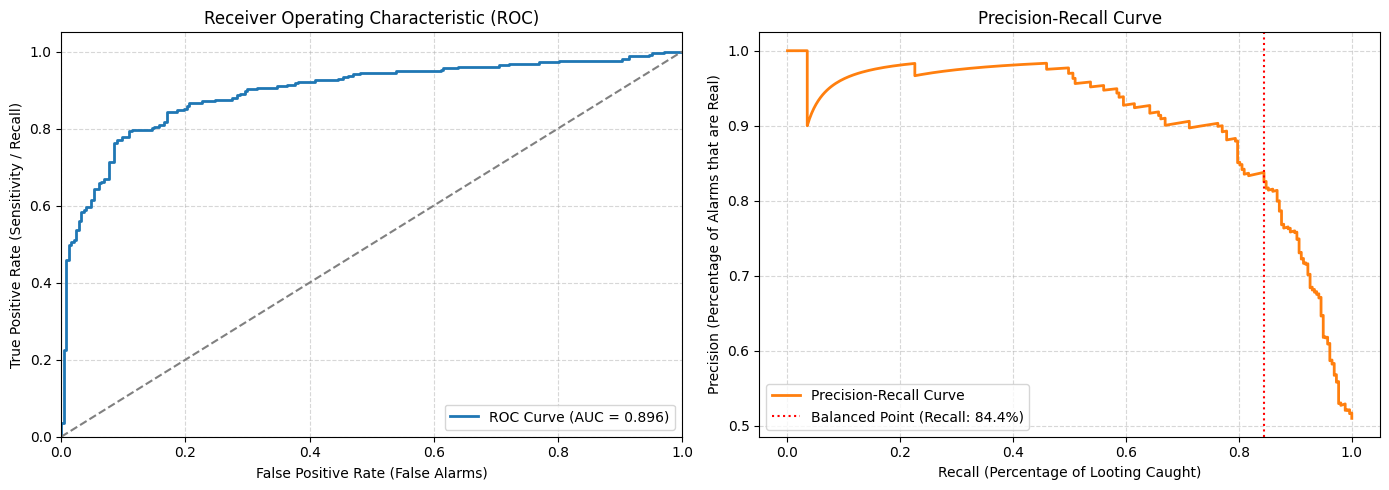

Mathematically Balanced Decision Threshold (Max F1-Score): 0.4007


In [16]:


# 1. Compute ROC curve metrics
fpr, tpr, thresholds_roc = roc_curve(labels_array, oof_probs)
roc_auc = auc(fpr, tpr)

# 2. Compute Precision-Recall curve metrics
precisions, recalls, thresholds_pr = precision_recall_curve(labels_array, oof_probs)

# 3. Find optimal threshold that maximizes the F1-Score
f1_scores = np.divide(2 * precisions * recalls, precisions + recalls, 
                      out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
best_idx = np.argmax(f1_scores)
# Safely handle index boundaries
best_threshold = thresholds_pr[best_idx-1] if best_idx < len(thresholds_pr) else 0.5

# 4. Generate Plots
plt.figure(figsize=(14, 5))

# Plot ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, color='#ff7f0e', lw=2, label='Precision-Recall Curve')
plt.axvline(x=recalls[best_idx], color='red', linestyle=':', label=f'Balanced Point (Recall: {recalls[best_idx]*100:.1f}%)')
plt.xlabel('Recall (Percentage of Looting Caught)')
plt.ylabel('Precision (Percentage of Alarms that are Real)')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Mathematically Balanced Decision Threshold (Max F1-Score): {best_threshold:.4f}")

In [18]:
def compare_thresholds(y_true, y_probs, t1=0.50, t2=0.4007):
    # Calculations for Default 0.50 Threshold
    preds1 = (y_probs >= t1).astype(int)
    tn1, fp1, fn1, tp1 = confusion_matrix(y_true, preds1).ravel()
    acc1 = (tp1 + tn1) / len(y_true) * 100
    rec1 = tp1 / (tp1 + fn1) * 100
    prec1 = tp1 / (tp1 + fp1) * 100 if (tp1 + fp1) > 0 else 0.0
    
    # Calculations for Optimized 0.4007 Threshold
    preds2 = (y_probs >= t2).astype(int)
    tn2, fp2, fn2, tp2 = confusion_matrix(y_true, preds2).ravel()
    acc2 = (tp2 + tn2) / len(y_true) * 100
    rec2 = tp2 / (tp2 + fn2) * 100
    prec2 = tp2 / (tp2 + fp2) * 100 if (tp2 + fp2) > 0 else 0.0
    
    # Output Side-by-Side Table
    print("=================================================================")
    print("           COMPARISON: STANDARD VS. BALANCED THRESHOLD")
    print("=================================================================")
    print(f"{'Performance Metric':<30} | {'Default (0.50)':<15} | {'Optimized (0.4007)':<15}")
    print("-" * 65)
    print(f"{'Overall Accuracy':<30} | {acc1:.2f}%{'':<9} | {acc2:.2f}%")
    print(f"{'Looting Detection Rate (Recall)':<30} | {rec1:.2f}%{'':<9} | {rec2:.2f}%")
    print(f"{'Dispatch Warning Acc (Precision)':<30} | {prec1:.2f}%{'':<9} | {prec2:.2f}%")
    print("-" * 65)
    print(f"{'Active Lootings Caught':<30} | {tp1:<5} / {tp1+fn1:<5}   | {tp2:<5} / {tp2+fn2:<5}")
    print(f"{'🛡️ Looting Incidents MISSED':<30} | {fn1:<14} | {fn2:<14}")
    print(f"{'⚠️ False Alarm Dispatches':<30} | {fp1:<14} | {fp2:<14}")
    print("=================================================================")

# Execute comparison
compare_thresholds(labels_array, oof_probs, t1=0.50, t2=0.4007)

           COMPARISON: STANDARD VS. BALANCED THRESHOLD
Performance Metric             | Default (0.50)  | Optimized (0.4007)
-----------------------------------------------------------------
Overall Accuracy               | 83.93%          | 83.53%
Looting Detection Rate (Recall) | 77.04%          | 84.44%
Dispatch Warning Acc (Precision) | 90.00%          | 83.46%
-----------------------------------------------------------------
Active Lootings Caught         | 198   / 257     | 217   / 257  
🛡️ Looting Incidents MISSED    | 59             | 40            
⚠️ False Alarm Dispatches      | 22             | 43            


In [22]:


# 1. Create a clean temporary directory to gather only the model files
temp_gather_dir = '/kaggle/working/resnet50_folds_ensemble'
if os.path.exists(temp_gather_dir):
    shutil.rmtree(temp_gather_dir) # Clear previous remnants
os.makedirs(temp_gather_dir, exist_ok=True)

print("Gathering your 5 fine-tuned fold models...")
copied_count = 0

for fold in range(1, 6):
    # Path variation A: If you trained them in this current active session
    local_path = f'/kaggle/working/resnet50_fold_{fold}_finetuned.pth'
    
    # Path variation B: If you are pulling them from your pre-uploaded Kaggle inputs
    input_path = f'/kaggle/input/models/abdelazizamr837/resnet50-fold-{fold}-finetuned-pth/pytorch/default/1/resnet50_fold_{fold}_finetuned.pth'
    
    destination_path = os.path.join(temp_gather_dir, f'resnet50_fold_{fold}.pth')
    
    if os.path.exists(local_path):
        shutil.copy(local_path, destination_path)
        print(f"  -> Fold {fold}: Found in local workspace. Copied.")
        copied_count += 1
    elif os.path.exists(input_path):
        shutil.copy(input_path, destination_path)
        print(f"  -> Fold {fold}: Found in imported inputs. Copied.")
        copied_count += 1
    else:
        print(f"  ⚠️ Warning: Could not find weights for Fold {fold} in local workspace or inputs.")

# 2. Only zip if we successfully collected all 5 models
if copied_count == 5:
    zip_output_path = '/kaggle/working/egypt_looting_5folds_ensemble'
    
    # Zip the temporary directory
    shutil.make_archive(zip_output_path, 'zip', temp_gather_dir)
    print(f"\n📦 Success! All 5 models are zipped into: {zip_output_path}.zip")
    print("You can download this file from your Kaggle output panel on the right sidebar.")
else:
    print(f"\n❌ Execution stopped: Only found {copied_count}/5 models.")
    print("Please ensure your models are fully trained or successfully imported before zipping.")

# 3. Clean up the temporary folder to keep your Kaggle workspace tidy
if os.path.exists(temp_gather_dir):
    shutil.rmtree(temp_gather_dir)

Gathering your 5 fine-tuned fold models...
  -> Fold 1: Found in imported inputs. Copied.
  -> Fold 2: Found in imported inputs. Copied.
  -> Fold 3: Found in imported inputs. Copied.
  -> Fold 4: Found in imported inputs. Copied.
  -> Fold 5: Found in imported inputs. Copied.

📦 Success! All 5 models are zipped into: /kaggle/working/egypt_looting_5folds_ensemble.zip
You can download this file from your Kaggle output panel on the right sidebar.


In [24]:
import pandas as pd
# 1. Define paths and parameters
export_dir = '/kaggle/working/model_evaluation_assets'
os.makedirs(export_dir, exist_ok=True)

OPTIMIZED_THRESHOLD = 0.4007
preds_optimized = (oof_probs >= OPTIMIZED_THRESHOLD).astype(int)

# 2. Re-create and save a high-resolution Confusion Matrix Plot (300 DPI for print)
print("Generating high-resolution Confusion Matrix plot...")
cm = confusion_matrix(labels_array, preds_optimized)
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NotLooted', 'Looted'])
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)

plt.title(f"Optimized Confusion Matrix (Threshold: {OPTIMIZED_THRESHOLD})", fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()

plot_save_path = os.path.join(export_dir, 'confusion_matrix_optimized.png')
plt.savefig(plot_save_path, bbox_inches='tight')
plt.close()
print(f"  -> Saved plot to: {plot_save_path}")

# 3. Compile a complete Out-of-Fold (OOF) CSV Prediction Log
print("\nCompiling full prediction log spreadsheet...")
image_filenames = [os.path.basename(path) for path in base_dataset.image_paths]

results_df = pd.DataFrame({
    'Image_File_Name': image_filenames,
    'True_Label': [base_dataset.classes[int(l)] for l in labels_array],
    'Computed_Looting_Probability': oof_probs,
    'Prediction_At_0.50_Threshold': [base_dataset.classes[int(p)] for p in oof_preds],
    'Prediction_At_Optimized_0.4007_Threshold': [base_dataset.classes[int(p)] for p in preds_optimized]
})

csv_save_path = os.path.join(export_dir, 'out_of_fold_predictions_analysis.csv')
results_df.to_csv(csv_save_path, index=False)
print(f"  -> Saved spreadsheet to: {csv_save_path}")

# 4. Zip the assets together for unified download
zip_output_path = '/kaggle/working/archaeological_model_results'
shutil.make_archive(zip_output_path, 'zip', export_dir)
print(f"\n📦 Success! All evaluation files are zipped into: {zip_output_path}.zip")
print("You can download the package from your Kaggle Output pane on the right sidebar.")

# 5. Clean up temporary export directory
if os.path.exists(export_dir):
    shutil.rmtree(export_dir)

Generating high-resolution Confusion Matrix plot...
  -> Saved plot to: /kaggle/working/model_evaluation_assets/confusion_matrix_optimized.png

Compiling full prediction log spreadsheet...
  -> Saved spreadsheet to: /kaggle/working/model_evaluation_assets/out_of_fold_predictions_analysis.csv

📦 Success! All evaluation files are zipped into: /kaggle/working/archaeological_model_results.zip
You can download the package from your Kaggle Output pane on the right sidebar.
